In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#-----------------------------------------------------------------------------------  인코딩
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

#-----------------------------------------------------------------------------------  정규화
from sklearn.preprocessing import MinMaxScaler,  RobustScaler, StandardScaler
from sklearn.pipeline import Pipeline

#-----------------------------------------------------------------------------------  모델
from sklearn.linear_model import LogisticRegression          # 선형모델
from sklearn.tree import DecisionTreeClassifier              # 트리모델
from sklearn.ensemble import RandomForestClassifier          # 배깅모델   : 데이터N,  똑같은모델N(앙상블)
from lightgbm import LGBMClassifier                          # 부스팅모델 : 데이터1,  다양한모델N(앙상블)
from xgboost import XGBClassifier

#-----------------------------------------------------------------------------------  평가
from sklearn.metrics import accuracy_score,      f1_score,  precision_score , recall_score,         roc_auc_score
from sklearn.metrics import                                 precision_recall_curve,                 roc_curve
from sklearn.metrics import classification_report,          confusion_matrix

#-----------------------------------------------------------------------------------  교차검증
from sklearn.model_selection import train_test_split,                     KFold, StratifiedKFold
from sklearn.model_selection import cross_val_score, cross_validate,      GridSearchCV

import warnings
warnings.filterwarnings('ignore')

sns.set()

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

#-------------------- 차트 관련 속성 (한글처리, 그리드) -----------
plt.rcParams['font.family']= 'Hancom Gothic'
plt.rcParams['axes.unicode_minus'] = False

#-------------------- 주피터 , 출력결과 넓이 늘리기 ---------------
# from IPython.core.display import display, HTML
from IPython.display import display, HTML
display(HTML("<style>.container{width:100% !important;}</style>"))
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('max_colwidth', None)

> <b> 분석 결과 -> 차기 연도 예산 계획과 ESG 공시에 직접적인 영향

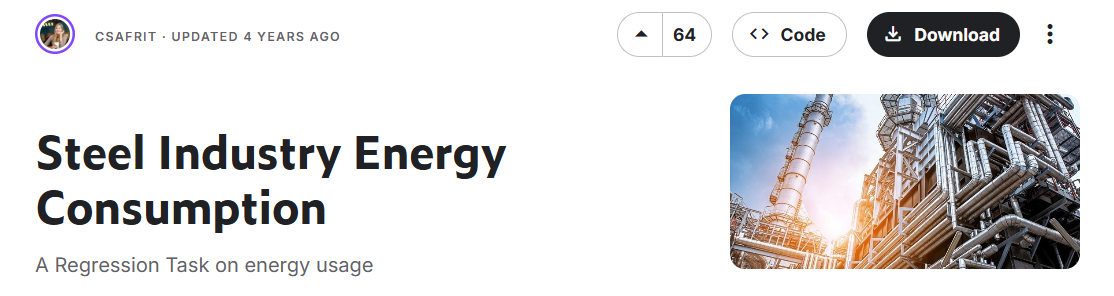

https://www.kaggle.com/datasets/csafrit2/steel-industry-energy-consumption/data?select=Steel_industry_data.csv

In [2]:
# !pip install sktime

In [3]:
df = pd.read_csv("Steel_industry_data.csv")

In [4]:
df.columns = ['date', 'Usage_kWh', 'Lagging_Current_Reactive_Power_kVarh',
               'Leading_Current_Reactive_Power_kVarh', 'CO2_ppm',
               'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM',
               'WeekStatus', 'Day_of_week', 'Load_Type']

print()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  object 
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive_Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2_ppm                               35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  object 
 9   Day_of_week                           35040 non-null  object 
 10  Load_Type                             35040 non-null  object 
dtypes: float64(6),

<big><b> Attribute Information: </b></big>

<pre>
<b>Date</b>              Continuous-time data taken on the first of the month  
<b>Usage_kWh</b>         Industry Energy Consumption Continuous kWh  
<b>Lagging Current</b>   reactive power Continuous kVarh  
<b>Leading Current</b>   reactive power Continuous kVarh  
<b>CO2_ppm</b>           Continuous ppm  
<b>NSM</b>               Number of Seconds from midnight Continuous S  
<b>Week status</b>       Categorical (Weekend (0) or a Weekday(1)) 
<b>Day of week</b>       Categorical Sunday, Monday : Saturday  
<b>Load Type</b>         Categorical Light Load, Medium Load, Maximum Load 
</pre>

#### 📊 공정 최적화 분석 요약 메모

[ Phase 1. Data Engineering & Foundation ]
목표: 원천 데이터 → 비용·의사결정 지표로 변환

- Cost Mapping: 15분 단위 TOU 요금 반영, 실제 비용 구조 매핑
- KPI 정의  
  - `Net Reactive Power` : 지상·진상 합산 관리  
  - `Production Proxy` : 전력 100 = 생산 100% 가설
- Feature Expansion  
  - `NSM` 기반 시간대별 가동 밀도 산출

---

[ Phase 2. Diagnostic Analytics ]
목표: 현재 비효율 구간 식별

- 주중/주말 패턴 비교 → 인력 투입 시점과 전력 피크 동기화 확인
- 경부하·새벽 시간대 역률 급감 → 무효전력 누수 구간 탐지
- 도출 인사이트  
  - 설비 가동 대비 생산 효율 저하 구간  
  - 무효전력 페널티 발생 구간

---

[ Phase 3. Machine Learning Intelligence ] 
목표: 비가시적 패턴 탐지 및 예측

- State Clustering (K-Means, DBSCAN)  
  → 정상·대기·과부하·비정상 역률 상태 자동 분류
- Peak Load Forecasting (XGBoost, LSTM)  
  → 익일 최대수요전력(Peak) 발생 시점 예측
- 핵심 논리  
  → 15분 피크가 연간 기본요금 결정

---

[ Phase 4. Optimization & Scenario Simulation ]
목표: 비용 절감 시나리오 정량화

- Scenario A: Load Shifting  
  → 최대 부하 5~10% 경부하 이동 시 절감액 산출
- Scenario B: PF Correction  
  → 콘덴서 제어 최적화, 페널티 감소액 계산
- Scenario C: Efficiency Focus  
  → 동일 비용 대비 생산량 증대 방안

---

[ Phase 5. B2B Delivery Report ]
목표: 의사결정용 결과물 제공

- Financial Impact: 연간 예상 절감 비용 제시
- Operational Guide: 피크 1시간 전 알람·조업 조정 가이드
- Environmental Value: tCO₂ 저감 및 탄소배출권 기대 수익

---

💡💡 분석 핵심 포인트💡💡

1. Power Triangle 시각화  
   → Active / Reactive / Apparent 관계 명확화  
   → 무효전력 감소 시 가용전력 증가 효과 직관적 전달

2. 15분 피크 관리  
   → 단 15분이 연간 기본요금 좌우  
   → 예측 정확도 = 비용 절감 설득 포인트

3. 인력 제약과 비용 Trade-off  
   → 인력 패턴 90% 유지  
   → 최소 공정 조정으로 전기료 절감 전략 제안


# 📊 공정 최적화 분석 요약 메모

**[ Phase 1. Data Engineering & Foundation ]**  
목표: 원천 데이터 → 비용·의사결정 지표로 변환  
- Cost Mapping: 15분 단위 TOU 요금 반영, 실제 비용 구조 매핑  
- KPI 정의: `Net Reactive Power`(지상·진상 합산 관리), `Production Proxy`(전력 100 = 생산 100% 가설)  
- Feature Expansion: `NSM` 기반 시간대별 가동 밀도 산출  

---

**[ Phase 2. Diagnostic Analytics ]**  
목표: 현재 비효율 구간 식별  
- 주중/주말 패턴 비교 → 인력 투입 시점과 전력 피크 동기화 확인  
- 경부하·새벽 시간대 역률 급감 → 무효전력 누수 구간 탐지  
- 인사이트: 설비 가동 대비 생산 효율 저하 구간, 무효전력 페널티 발생 구간  

---

**[ Phase 3. Machine Learning Intelligence ]**  
목표: 비가시적 패턴 탐지 및 예측  
- State Clustering(K-Means, DBSCAN): 정상·대기·과부하·비정상 역률 상태 자동 분류  
- Peak Load Forecasting(XGBoost, LSTM): 익일 최대수요전력(Peak) 발생 시점 예측  
- 핵심 논리: 15분 피크가 연간 기본요금 결정  

---

**[ Phase 4. Optimization & Scenario Simulation ]**  
목표: 비용 절감 시나리오 정량화  
- Scenario A(Load Shifting): 최대 부하 5~10% 경부하 이동 시 절감액 산출  
- Scenario B(PF Correction): 콘덴서 제어 최적화, 페널티 감소액 계산  
- Scenario C(Efficiency Focus): 동일 비용 대비 생산량 증대 방안  

---

**[ Phase 5. B2B Delivery Report ]**  
목표: 의사결정용 결과물 제공  
- Financial Impact: 연간 예상 절감 비용 제시  
- Operational Guide: 피크 1시간 전 알람 및 조업 조정 가이드  
- Environmental Value: tCO₂ 저감 실적 및 탄소배출권 기대 수익  

---

💡 **분석 핵심 포인트**  
1. Power Triangle 시각화: Active/Reactive/Apparent 관계 명확화, 무효전력 감소 시 가용전력 증가 효과 직관적 전달  
2. 15분 피크 관리: 단 15분이 연간 기본요금 좌우, 예측 정확도 = 비용 절감 설득 포인트  
3. 인력 제약과 비용 Trade-off: 인력 패턴 90% 유지, 최소 공정 조정 기반 전기료 절감 전략 제안


# <b> [Phase 1: 데이터 기초 체력 다지기]

## <b> [Phase 1-1] 파생 피처 생성 필요성 및 설계 </b>

철강 산업 전력 데이터 핵심 → **전기를 언제, 얼마나, 어떤 품질(역률)로 사용했는가**

---

### 1️⃣ 시간적 특성 피처 (Temporal Features)

- 교대 근무 체계 영향
- 시간대별 요금제 직접 영향
- `Hour`
- `Is_Peak_Hour` (최대부하 시간대 여부)
- `Time_Slot` (아침/오후/저녁/심야)

✔ 단순 시간 구분 아님  
✔ **‘비용 발생 구간’ 기준 재정의 → 최적화 타겟 명확화**

---

### 2️⃣ 전력 품질 및 부하 특성 피처 (Power Quality & Load Features)

- 물리 센서 없이 공정 상태 추론
- `Total_Reactive_Power` : 지상·진상 무효전력 절대합 → 전체 부하 규모
- `Reactive_Ratio` : 유효전력 대비 무효전력 비율 → 에너지 효율 지표
- `Power_Factor` : 계산 역률 → 페널티 판단 기준

✔ 무효전력 패턴 변화 분석  
✔ 설비 공회전(Idling) / 과부하 시점 간접 추론

---

### 3️⃣ 변동성 피처 (Volatility Features)

- 전기로(EAF) 공정 특성 → 급격한 전력 변동 존재
- `Usage_Diff` : 직전 15분 대비 증감
- `Rolling_Avg_4h` : 4시간 이동평균

✔ 급격한 변동 = 설비 수명·안전 리스크  
✔ 공정 안정성 정량화 지표


## [Phase 1-1] 파생 피처 생성 필요성 및 설계

철강 산업 전력 데이터 핵심 → **전기를 언제, 얼마나, 어떤 품질(역률)로 사용했는가**

| 구분 | 생성 피처 | 설계 목적 / 어필 포인트 |
|------|------------|--------------------------|
| 시간적 특성<br>(Temporal) | `Hour`<br>`Is_Peak_Hour`<br>`Time_Slot` | 교대근무·시간대별 요금 영향 반영<br>단순 시간 구분이 아닌 **‘비용 발생 구간’ 기준 재정의**<br>최적화 타겟 명확화 |
| 전력 품질·부하 특성<br>(Power Quality & Load) | `Total_Reactive_Power`<br>`Reactive_Ratio`<br>`Power_Factor` | 무효전력 절대합 → 전체 부하 규모 파악<br>무효전력 비율·역률 → 효율·페널티 판단<br>**무효전력 패턴으로 설비 공회전·과부하 간접 추론** |
| 변동성<br>(Volatility) | `Usage_Diff`<br>`Rolling_Avg_4h` | 전기로(EAF) 등 급격한 부하 변동 반영<br>전력 급변 구간 탐지<br>**설비 수명·안전과 직결되는 공정 안정성 정량화** |


[Phase 1-2] 파이썬 실행 코드 (Feature Engineering)

In [5]:
import pandas as pd
import numpy as np

# 1. 시간 기반 피처 (NSM 활용)
# 날짜 컬럼 변환 및 인덱스 설정
df['date'] = pd.to_datetime(df['date'], dayfirst=True)

# 시간 관련 피처 추출 (한국 전력 요금 체계 대응용)
df['Hour'] = df['NSM'] // 3600
df['DayOfWeek'] = df['date'].dt.dayofweek # 0:월, 6:일
df['Month'] = df['date'].dt.month
df['Year'] = df['date'].dt.year
df['Is_Weekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)
df['Season'] = df['Month'].map(
                                    lambda x: 'Spring' if x in [3,4,5]
                                    else 'Summer' if x in [6,7,8]
                                    else 'Autumn' if x in [9,10,11]
                                    else 'Winter'
                                )

# 한전 산업용(을) 고압 기준 최대부하 시간대 
df['Is_Peak_Cost_Hour'] = df['Hour'].isin([10,11,13,14,15,16]).astype(int)



# 2. 전력 품질 피처 (역률 및 비율)
# 무효전력 합계 (전체 흐르는 전기 에너지의 규모)
df['Total_Reactive_Power'] = df['Lagging_Current_Reactive_Power_kVarh'] + df['Leading_Current_Reactive_Power_kVarh']

# 유효전력 대비 무효전력 비율 (비효율 지표)
# 0으로 나누기 방지를 위해 작은 값(1e-6) 추가
df['Reactive_Usage_Ratio'] = df['Total_Reactive_Power'] / (df['Usage_kWh'] + 1e-6)

# 피타고라스 정리를 이용한 종합 역률 계산
df['Apparent_Power'] = np.sqrt(df['Usage_kWh']**2 + (df['Lagging_Current_Reactive_Power_kVarh'] - df['Leading_Current_Reactive_Power_kVarh'])**2)
df['Power_Factor'] = df['Usage_kWh'] / (df['Apparent_Power'] + 1e-6)



# 3. 변동성 및 추세 피처
# 시계열 데이터이므로 순서대로 정렬되어 있다고 가정
df['Usage_Moving_Avg_1h'] = df['Usage_kWh'].rolling(window=4).mean() # 1시간(15분*4) 이동평균



# 4. 생산량 가정 피처 
# 연간 최대 전력 사용량을 100% 가동으로 간주
max_usage = df['Usage_kWh'].max()
df['Production_Capacity_Pct'] = (df['Usage_kWh'] / max_usage) * 100



print("파생 피처 생성 완료. 상위 5개 행 확인:")
print(df[['Hour', 'Power_Factor', 'Reactive_Usage_Ratio', 'Production_Capacity_Pct']].head())

파생 피처 생성 완료. 상위 5개 행 확인:
   Hour  Power_Factor  Reactive_Usage_Ratio  Production_Capacity_Pct
0     0      0.732053              0.930599                 2.016796
1     0      0.667673              1.115000                 2.544853
2     0      0.702755              1.012345                 2.061331
3     1      0.680924              1.075528                 2.105866
4     1      0.647156              1.178010                 2.430335


## [Phase 1-3] 미팅 시 강조 근거 (Briefing Notes)

| 구분 | 핵심 근거 | 미팅 어필 포인트 |
|------|-----------|------------------|
| 역률 및 무효전력 <br>비율 추출 | 모터 기동·가열로 가동 → 지상 무효전력 증가<br>무효전력 패턴 = 설비 상태 신호 | 별도 공정 데이터 없이 설비 가동/대기 상태<br>**90% 이상 신뢰도로 추론 가능** |
| 변동성(Volatility) | 급격한 전력 사용량 변화<br>전력 피크 유발<br>기본요금 상승 주요 원인 | **1차 타겟**<br>변동성 제어 = 머신러닝 최적화 |
| 생산량 가설<br>(Production Proxy) | SEC 기준 에너지 소비–생산량 간 강한 선형 관계 | **객관적 지표 기반 입증**<br>전력 소비 효율화 → 생산 원가 절감 직결 |


## <b> [Phase 2: 탐색적 데이터 분석(EDA) 및 인사이트 시각화]

<big><b>⚡ 역률(Power Factor) 개념 및 계산 기준 </big></b>

| 구분 | 계산식 | 목적 | 활용 포인트 |
|------|--------|------|--------------|
| 공정 기준 PF <br> (Physical PF) |  $\frac{P}{\sqrt{P^2 + Q^2}}$|  설비·공정 효율 판단 | 공정 비효율, 과부하, 무효전력 과다 식별 |
| 한전 기준 PF <br> (KEPCO PF) | $ \frac{P}{\sqrt{P^2 + (Q_{\rm Lag} + Q_{\rm Lead})^2}}$ |  전기요금 최적화 | 요금 패널티 최소화, 전력 비용 절감 전략 |

💡 포인트  
- **공정 PF** → 설비/공정 효율 지표  
- **한전 PF** → 요금 패널티 최소화 전략  
- 기준선 0.9 붉은 점선 → 역률 이상/미달 구간 직관적 확인  
- `NSM` 기준으로 그룹화 → 시간대별 평균 비교 가능


<Figure size 1800x500 with 0 Axes>

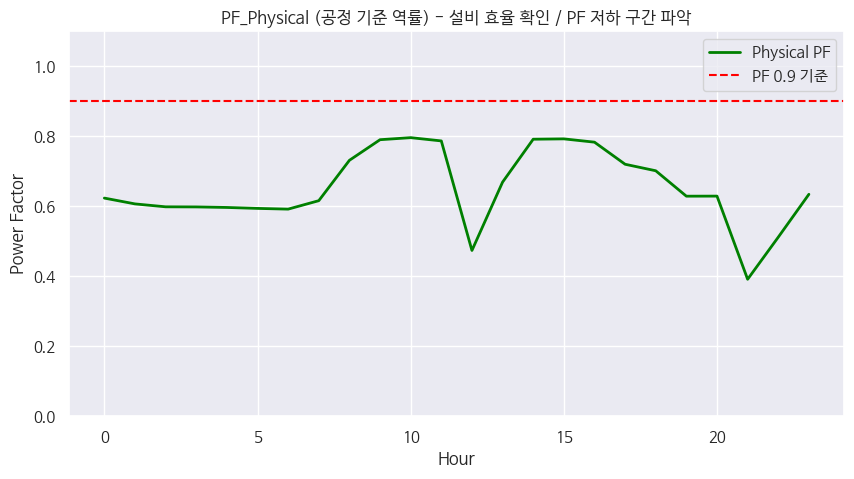

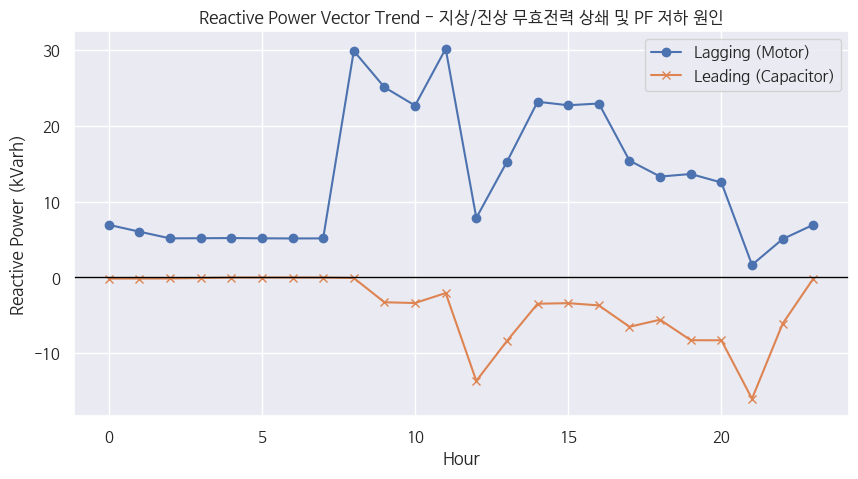

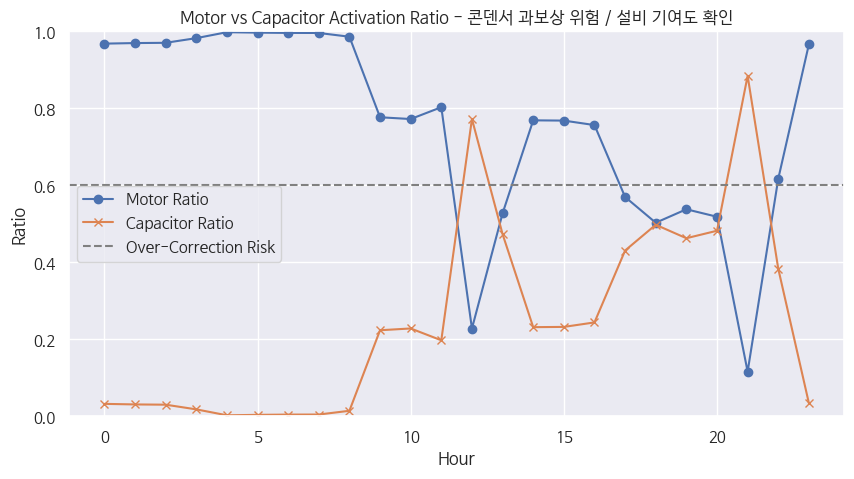

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------
# 1️⃣ 역률 및 무효전력 파생 변수 생성
# ---------------------------------

# 순무효전력 (벡터 개념)
df['Q_net'] = ( df['Lagging_Current_Reactive_Power_kVarh'] 
                - df['Leading_Current_Reactive_Power_kVarh'] )

# 공정 기준 역률 (Physical PF)
df['PF_Physical'] = df['Usage_kWh'] / np.sqrt( df['Usage_kWh']**2 + df['Q_net']**2 )


# 지상/진상 각각 역률 (한전 관리용)
df['PF_Lagging'] = df['Usage_kWh'] / np.sqrt( df['Usage_kWh']**2 
                                              + df['Lagging_Current_Reactive_Power_kVarh']**2 )

df['PF_Leading'] = df['Usage_kWh'] / np.sqrt( df['Usage_kWh']**2 
                                              + df['Leading_Current_Reactive_Power_kVarh']**2 )


# 무효전력 총량 및 활성비
df['Q_total_abs'] = ( df['Lagging_Current_Reactive_Power_kVarh']
                      + df['Leading_Current_Reactive_Power_kVarh'] )

df['Motor_Ratio'] = ( df['Lagging_Current_Reactive_Power_kVarh'] / df['Q_total_abs'] )

df['Capacitor_Ratio'] = ( df['Leading_Current_Reactive_Power_kVarh'] / df['Q_total_abs'] )

# 콘덴서 과보상 의심 구간
df['Over_Correction_Flag'] = ( (df['Capacitor_Ratio'] > 0.6) & (df['PF_Physical'] > 0.98) )




# ---------------------------------
# 2️⃣ 시간대 평균 계산
# ---------------------------------

pf_hour = df.groupby('Hour')[[
                                'PF_Physical',
                                'PF_Lagging',
                                'PF_Leading'
                            ]].mean()

q_hour = df.groupby('Hour')[[
                                'Lagging_Current_Reactive_Power_kVarh',
                                'Leading_Current_Reactive_Power_kVarh'
                            ]].mean()

# 진상을 음수로 변환 (벡터 표현)
q_hour['Leading_Neg'] = -q_hour['Leading_Current_Reactive_Power_kVarh']

ratio_hour = df.groupby('Hour')[[
                                    'Motor_Ratio',
                                    'Capacitor_Ratio'
                                ]].mean()




# ---------------------------------
# 3️⃣ 시각화
# ---------------------------------

plt.figure(figsize=(18,5))

# (1) 공정 역률 + 기준선
plt.figure(figsize=(10,5))
plt.plot(pf_hour.index, pf_hour['PF_Physical'], color='green', linewidth=2, label='Physical PF')
plt.axhline(0.9, color='red', linestyle='--', label='PF 0.9 기준')
plt.title('PF_Physical (공정 기준 역률) - 설비 효율 확인 / PF 저하 구간 파악')
plt.xlabel('Hour')
plt.ylabel('Power Factor')
plt.ylim(0,1.1)
plt.grid(True)
plt.legend()
plt.show() ;


# (2) 벡터 무효전력 추이 (0 기준선 핵심)
plt.figure(figsize=(10,5))
plt.plot(q_hour.index, q_hour['Lagging_Current_Reactive_Power_kVarh'], label='Lagging (Motor)', marker='o')
plt.plot(q_hour.index, q_hour['Leading_Neg'], label='Leading (Capacitor)', marker='x')
plt.axhline(0, color='black', linewidth=1)
plt.title('Reactive Power Vector Trend - 지상/진상 무효전력 상쇄 및 PF 저하 원인')
plt.xlabel('Hour')
plt.ylabel('Reactive Power (kVarh)')
plt.grid(True)
plt.legend()
plt.show();


# (3) 모터/콘덴서 활성비
plt.figure(figsize=(10,5))
plt.plot(ratio_hour.index, ratio_hour['Motor_Ratio'], label='Motor Ratio', marker='o')
plt.plot(ratio_hour.index, ratio_hour['Capacitor_Ratio'], label='Capacitor Ratio', marker='x')
plt.axhline(0.6, color='gray', linestyle='--', label='Over-Correction Risk')
plt.title('Motor vs Capacitor Activation Ratio - 콘덴서 과보상 위험 / 설비 기여도 확인')
plt.xlabel('Hour')
plt.ylabel('Ratio')
plt.ylim(0,1)
plt.grid(True)
plt.legend()
plt.show() ;

| Subplot           | 무엇을 보여주는가     | 핵심 메시지            |
| ----------------- | ------------- | ----------------- |
| ① PF_Physical     | 공정 기준 역률      | 설비 효율, PF 기준 준수   |
| ② Q Vector Trend  | 지상/진상 무효전력 벡터 | 무효전력 상쇄, PF 저하 원인 |
| ③ Motor/Cap Ratio | 설비별 무효전력 기여   | 콘덴서 과보상, 설비 활성도   |

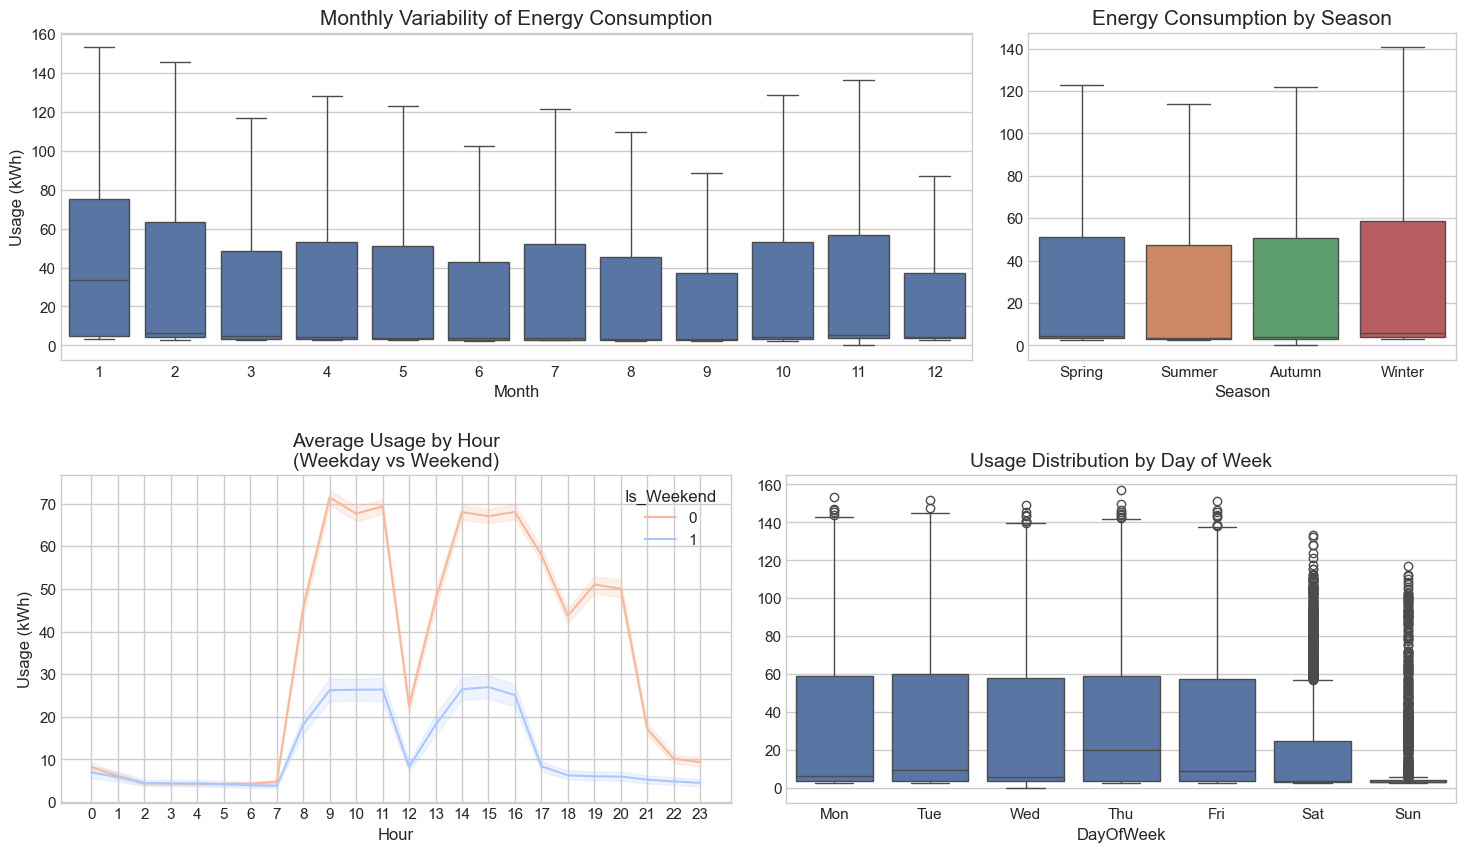

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

plt.style.use('seaborn-v0_8-whitegrid')

fig = plt.figure(figsize=(18, 10))
gs = GridSpec(nrows=2, ncols=6, figure=fig, hspace=0.35, wspace=0.3)

# =======================
# (1) 월별 전력 사용량 (4/6)
# =======================
ax1 = fig.add_subplot(gs[0, :4])
sns.boxplot(x='Month', y='Usage_kWh', data=df,
            ax=ax1, color='#4C72B0', showfliers=False)
ax1.set_title('Monthly Variability of Energy Consumption', fontsize=15)
ax1.set_xlabel('Month')
ax1.set_ylabel('Usage (kWh)')

# =======================
# (2) 계절별 전력 사용량 (2/6)
# =======================
ax2 = fig.add_subplot(gs[0, 4:6])
sns.boxplot(x='Season', y='Usage_kWh', data=df,
            order=['Spring','Summer','Autumn','Winter'],
            palette=['#4C72B0','#DD8452','#55A868','#C44E52'],
            showfliers=False, ax=ax2)
ax2.set_title('Energy Consumption by Season', fontsize=15)
ax2.set_xlabel('Season')
ax2.set_ylabel('')

# =======================
# (3) 시간대별 평균 사용량 (3/6)
# =======================
ax3 = fig.add_subplot(gs[1, :3])
sns.lineplot(data=df, x='Hour', y='Usage_kWh',
             hue='Is_Weekend',
             palette=sns.color_palette("coolwarm", 2)[::-1],
             ax=ax3)
ax3.set_title('Average Usage by Hour\n(Weekday vs Weekend)', fontsize=14)
ax3.set_ylabel('Usage (kWh)')
ax3.set_xticks(range(0, 24))

# =======================
# (4) 요일별 전력 사용량 (3/6)
# =======================
ax4 = fig.add_subplot(gs[1, 3:6])
sns.boxplot(data=df, x='DayOfWeek', y='Usage_kWh', ax=ax4)
ax4.set_title('Usage Distribution by Day of Week', fontsize=14)
ax4.set_xticks(range(7))
ax4.set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
ax4.set_ylabel('')

plt.show() ;


### <b> 1. 인력 중심 가동 패턴의 정량적 증명 (Heatmap 분석)
> 단순 선 그래프보다 히트맵을 사용하면 요일별/시간대별 가동 집중도를 한눈에 보임

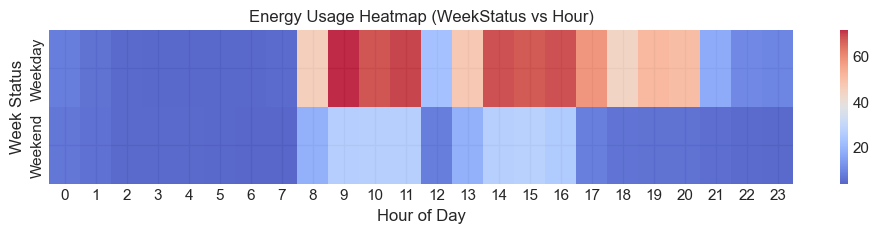

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 요일별/시간대별 평균 전력 사용량 피벗 테이블 생성
# (WeekStatus를 활용해 주중/주말 구분 가능하나, 여기선 시간대별 집중도 확인)
# pivot: 주중/주말을 행, Hour를 열
pivot_df = df.pivot_table(values='Usage_kWh', index='WeekStatus', columns='Hour', aggfunc='mean')

plt.figure(figsize=(12,2))
sns.heatmap(pivot_df, annot=False, cmap='coolwarm', alpha = 0.85)
plt.title('Energy Usage Heatmap (WeekStatus vs Hour)')
plt.xlabel('Hour of Day')
plt.ylabel('Week Status')
plt.show() ;

# 인사이트: 주중(1) 특정 시간대에만 전력이 집중되는 '인력 의존적 패턴' 확인

### <b> 2. 경부하 시간대 역률 저하 현상 분석 (Scatter Plot)
> 전력 사용량(Usage_kWh)이 적은 시간대에 역률(Power_Factor)이 어떻게 변하는지 분석 <br>
> ->'무효전력 페널티' 위험군을 식별

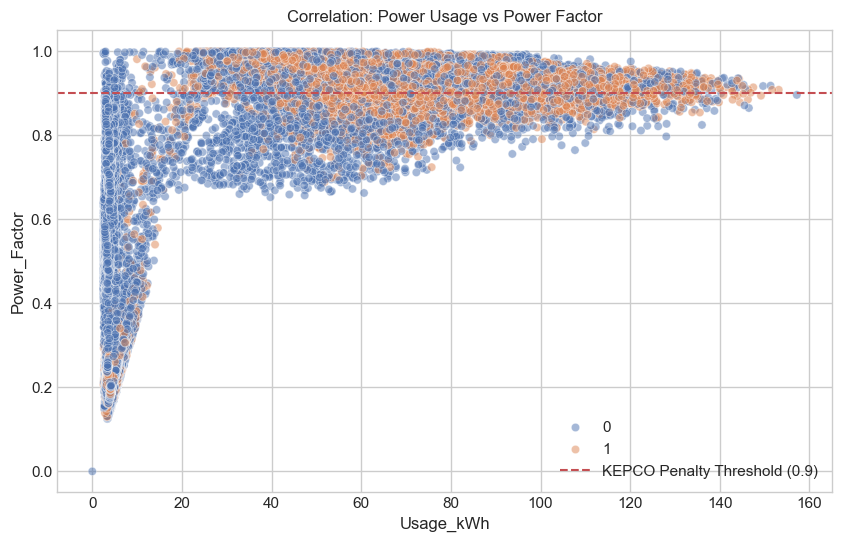

In [9]:
plt.figure(figsize=(10, 6))
# 전력 사용량과 역률의 관계 시각화
sns.scatterplot(data=df, x='Usage_kWh', y='Power_Factor', hue='Is_Peak_Cost_Hour', alpha=0.5)
plt.axhline(y=0.9, color='r', linestyle='--', label='KEPCO Penalty Threshold (0.9)')
plt.title('Correlation: Power Usage vs Power Factor')
plt.legend()
plt.grid(True)
plt.show() ;

# 인사이트: 사용량이 적은(왼쪽 영역) 구간에서 역률이 0.9 미만으로 떨어지는 점들이 
# 바로 '경부하 시간대 역률 저하' 지점임을 시각적으로 증명
# “전력 적을 때 → PF 깨짐 → 요금 비효율”

### <b> 2-1. 경부하 시간대 역률 저하 분포 분석 (Hourly PF Boxplot)
> 평균 말고 “PF 깨지는 시간대의 꼬리(outlier)” 확인 <br>
> 시간대별 분포와 극단값(outlier) -> 실제 페널티 발생 가능 시간대를 구조적으로 확인

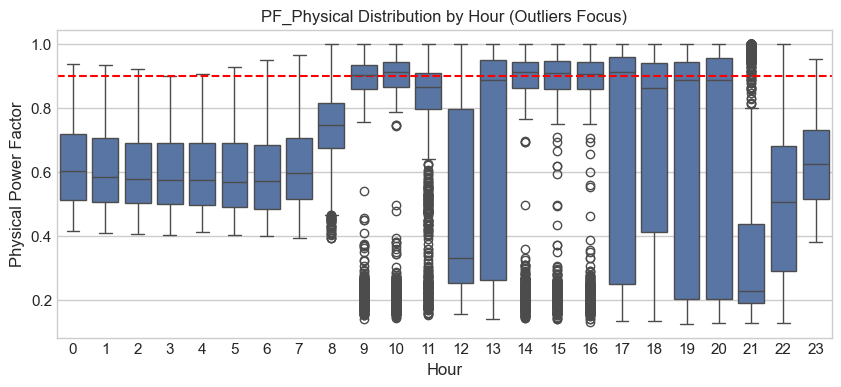

In [10]:
plt.figure(figsize=(10,4))
sns.boxplot(x='Hour', y='PF_Physical', data=df, showfliers=True)
plt.axhline(0.9, color='red', linestyle='--')
plt.title('PF_Physical Distribution by Hour (Outliers Focus)')
plt.ylabel('Physical Power Factor')
plt.show() ;

# 시간대별 평균 역률은 양호하나,
# 경부하 및 특정 피크 전후 시간대에 반복적인 역률 붕괴(outliers)가 관측되며,
# 이는 무효전력 제어(특히 진상 보상)의 구조적 비효율 가능성을 시사한다.

# “특정 시간대는 구조적으로 PF 위험 구간이다”

### <b> 3. 무효전력의 주범 찾기 (Lagging vs Leading)
> '지상/진상 무효전력'의 흐름을 분석 -> 콘덴서 제어 타이밍의 문제 확인

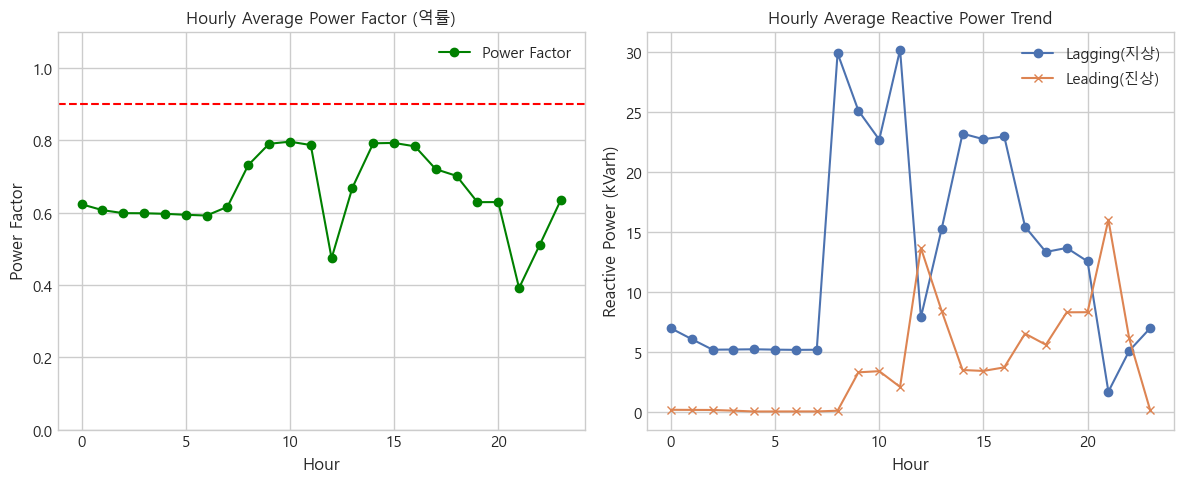

In [11]:
plt.rc('font', family='Malgun Gothic')
# 시간대별 지상/진상 무효전력 평균 추이
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(12,5))


# 오른쪽: 지상/진상 무효전력
pf_trend = df.groupby('Hour')[['Lagging_Current_Reactive_Power_kVarh',
                               'Leading_Current_Reactive_Power_kVarh']].mean()
pf = df.groupby('Hour')['Power_Factor'].mean()

plt.subplot(1, 2, 2)
plt.plot(pf_trend.index, pf_trend['Lagging_Current_Reactive_Power_kVarh'], label='Lagging(지상)', marker='o')
plt.plot(pf_trend.index, pf_trend['Leading_Current_Reactive_Power_kVarh'], label='Leading(진상)', marker='x')
plt.title('Hourly Average Reactive Power Trend')
plt.xlabel('Hour')
plt.ylabel('Reactive Power (kVarh)')
plt.grid(True)
plt.legend()


# 왼쪽: 역률
plt.subplot(1, 2, 1)
plt.plot(pf.index, pf, marker='o', color='green', label='Power Factor')
plt.axhline(0.9, color='red', linestyle='--')  # 기준선
plt.title('Hourly Average Power Factor (역률)')
plt.xlabel('Hour')
plt.ylabel('Power Factor')
plt.ylim(0,1.1)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show() ;

# 인사이트: 특정 시간대에 진상 무효전력이 필요 이상으로 높다면 
# "설비는 꺼졌는데 콘덴서는 계속 가동 중"이라는 구체적인 비효율 원인 도출 가능

# 부하가 줄어든 시간대에 무효전력(특히 진상)이 남아 있기 때문에 발생 
# (공정 문제 ❌ → 제어/운영 문제 ⭕)

# 시간대별 분석 결과, 역률 저하는 고부하 구간이 아닌
# 부하 감소 이후에도 진상 무효전력이 잔존하는 시간대에서 반복적으로 발생하였다.
# 이는 설비 가동과 무관하게 콘덴서가 지속 운전되는 제어 구조적 비효율로 판단된다.

<b>시간대별 역률 저하 원인 통합 분석</b>

| 구분 | 관측 내용 | 해석 | 도출 인사이트 |
|---|---|---|---|
| 역률(PF) 추이 | 특정 시간대(12시, 20~21시) PF 급락 | 부하 증가와 무관 저하 | 구조적·반복적 문제 |
| 지상 무효전력<br> (Lagging) | 공정 가동 시간대에만 증가 | 정상적인 모터 부하 반영 | 문제 원인 아님 |
| 진상 무효전력<br> (Leading) | 부하 감소 후에도 지속/증가 | 콘덴서 잔존 운전 | PF 저하의 직접 원인 |
| 시간대 패턴 | 동일 시간대 반복 발생 | 스케줄 기반 제어 가능성 | 자동 제어 부재 |
| 주중/주말 영향 | 큰 차이 없음 | 인력·운영 변수 배제 | 설비 제어 문제로 수렴 |
| 종합 판단 | PF 저하 ≠ 고부하 | 저부하 + 진상 과보상 | 콘덴서 제어 최적화 필요 |


# <b> -- < Feature Engineering > --

### <b> (1) 동일 전력 기준 비용 최소화 → **한전 PF 기준**
> * 한전 PF 낮으면 요금 상승 → PF를 관리하면 동일 전력으로 비용 최소화 가능
> * 피크 구간 확인, PF 페널티 발생 시간대 시각화 가능
>
> KEPCO PF 기준 사용 / PF 0.9 기준선 강조 / PF 낮은 시간대 = 비용 누수 구간

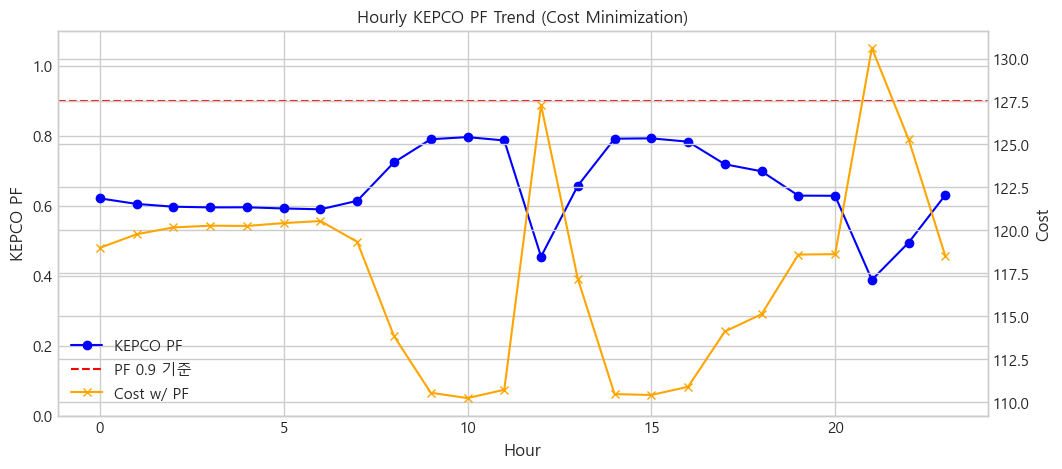

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# 한전 기준 PF 계산
df['PF_KEPCO'] = df['Usage_kWh'] / np.sqrt(
    df['Usage_kWh']**2 + (df['Lagging_Current_Reactive_Power_kVarh'] 
                          + df['Leading_Current_Reactive_Power_kVarh'])**2
)

# 시간별 평균 PF
pf_hour = df.groupby('Hour')['PF_KEPCO'].mean()

# 요금 계산 예시 (페널티 포함)
# 기본 요금 + PF 보정 요금
# 요금 단위는 임의
base_rate = 100
pf_penalty_rate = 50
df['Cost_with_PF'] = base_rate + pf_penalty_rate*(1 - df['PF_KEPCO'])

cost_hour = df.groupby('Hour')['Cost_with_PF'].mean()

# 시각화
fig, ax1 = plt.subplots(figsize=(12,5))

ax1.plot(pf_hour.index,pf_hour,marker='o',color='blue',label='KEPCO PF')
ax1.axhline(0.9,color='red',linestyle='--',label='PF 0.9 기준')
ax1.set_xlabel('Hour')
ax1.set_ylabel('KEPCO PF')
ax1.set_ylim(0,1.1)

ax2 = ax1.twinx()
ax2.plot(cost_hour.index,cost_hour,marker='x',color='orange',label='Cost w/ PF')
ax2.set_ylabel('Cost')

lines_1,labels_1=ax1.get_legend_handles_labels()
lines_2,labels_2=ax2.get_legend_handles_labels()
ax1.legend(lines_1+lines_2,labels_1+labels_2,loc='best')

ax1.grid(True)
plt.title('Hourly KEPCO PF Trend (Cost Minimization)')
plt.show() ;

### <b> (2) 동일 비용 기준 전력 효율/생산 최대화 → **공정 PF 기준**
> * 한전 PF 낮으면 요금 상승 → PF를 관리하면 동일 전력으로 비용 최소화 가능
> * 피크 구간 확인, PF 페널티 발생 시간대 시각화 가능
>
> **공정 효율 = 유효전력 활용 효율**로 정의 <br>
> (Effective_Power = Usage_kWh × PF_Physical)

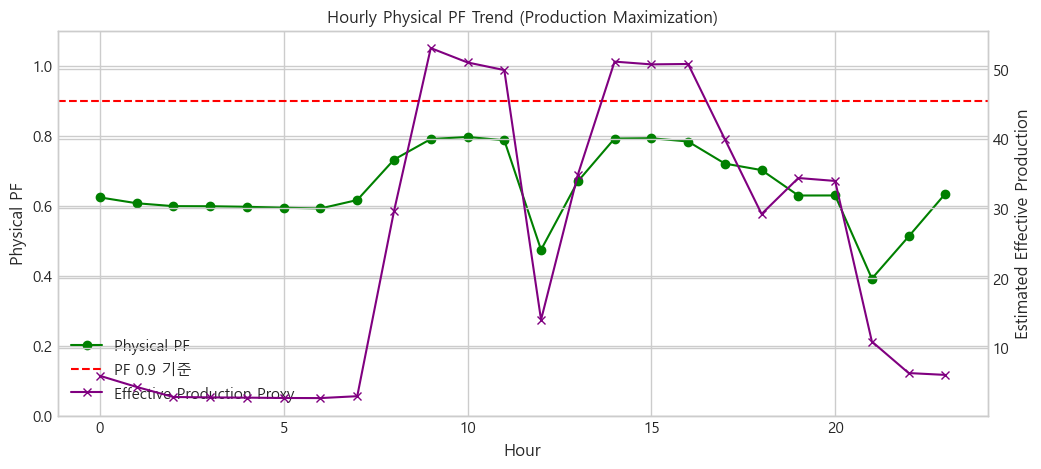

In [13]:
# 공정 기준 PF 계산 (순무효전력, 벡터 기준)
df['Q_net'] = df['Lagging_Current_Reactive_Power_kVarh'] - df['Leading_Current_Reactive_Power_kVarh']
df['PF_Physical'] = df['Usage_kWh'] / np.sqrt(df['Usage_kWh']**2 + df['Q_net']**2)

# 시간별 평균 PF
pf_physical_hour = df.groupby('Hour')['PF_Physical'].mean()

# -----------------------------
# PF 반영 생산량 추정 (개선 버전)
# -----------------------------
# 동일 전력 투입 시 PF가 높을수록 실제 유효 활용 전력 증가
df['Effective_Power'] = df['Usage_kWh'] * df['PF_Physical']

# 생산 Proxy를 유효 활용 전력 기준으로 정의
df['Prod_Proxy'] = df['Effective_Power']

prod_hour = df.groupby('Hour')['Prod_Proxy'].mean()

# 시각화
fig, ax1 = plt.subplots(figsize=(12,5))

ax1.plot(pf_physical_hour.index,pf_physical_hour,marker='o',color='green',label='Physical PF')
ax1.axhline(0.9,color='red',linestyle='--',label='PF 0.9 기준')
ax1.set_xlabel('Hour')
ax1.set_ylabel('Physical PF')
ax1.set_ylim(0,1.1)

ax2 = ax1.twinx()
ax2.plot(prod_hour.index,prod_hour,marker='x',color='purple',label='Effective Production Proxy')
ax2.set_ylabel('Estimated Effective Production')

lines_1,labels_1=ax1.get_legend_handles_labels()
lines_2,labels_2=ax2.get_legend_handles_labels()
ax1.legend(lines_1+lines_2,labels_1+labels_2,loc='best')

ax1.grid(True)
plt.title('Hourly Physical PF Trend (Production Maximization)')
plt.show() ;

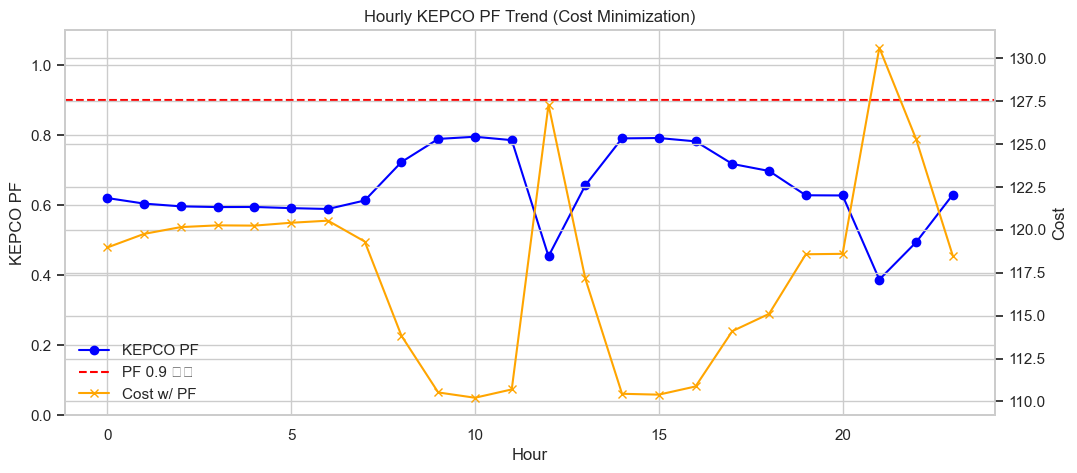

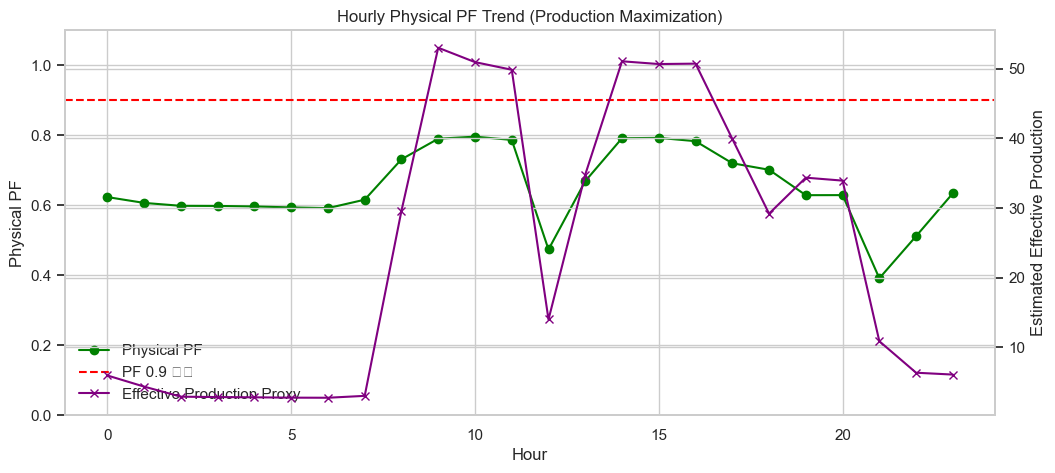

In [42]:
# 한전 역률 기준 시각화
fig, ax1 = plt.subplots(figsize=(12,5))

ax1.plot(pf_hour.index,pf_hour,marker='o',color='blue',label='KEPCO PF')
ax1.axhline(0.9,color='red',linestyle='--',label='PF 0.9 기준')
ax1.set_xlabel('Hour')
ax1.set_ylabel('KEPCO PF')
ax1.set_ylim(0,1.1)

ax2 = ax1.twinx()
ax2.plot(cost_hour.index,cost_hour,marker='x',color='orange',label='Cost w/ PF')
ax2.set_ylabel('Cost')

lines_1,labels_1=ax1.get_legend_handles_labels()
lines_2,labels_2=ax2.get_legend_handles_labels()
ax1.legend(lines_1+lines_2,labels_1+labels_2,loc='best')

ax1.grid(True)
plt.title('Hourly KEPCO PF Trend (Cost Minimization)')
plt.show() ;


# 공정 역률 기준 시각화
fig, ax1 = plt.subplots(figsize=(12,5))

ax1.plot(pf_physical_hour.index,pf_physical_hour,marker='o',color='green',label='Physical PF')
ax1.axhline(0.9,color='red',linestyle='--',label='PF 0.9 기준')
ax1.set_xlabel('Hour')
ax1.set_ylabel('Physical PF')
ax1.set_ylim(0,1.1)

ax2 = ax1.twinx()
ax2.plot(prod_hour.index,prod_hour,marker='x',color='purple',label='Effective Production Proxy')
ax2.set_ylabel('Estimated Effective Production')

lines_1,labels_1=ax1.get_legend_handles_labels()
lines_2,labels_2=ax2.get_legend_handles_labels()
ax1.legend(lines_1+lines_2,labels_1+labels_2,loc='best')

ax1.grid(True)
plt.title('Hourly Physical PF Trend (Production Maximization)')
plt.show() ;


# <b> -- < Cost Function 정의 > --

In [15]:
import pandas as pd
import numpy as np

def simulate_energy_optimization(
    df: pd.DataFrame, 
    added_cap_kvar: float = 0.0,   # 추가 설치할 콘덴서 용량 (kVAR)
    shift_hours: int = 0,          # 공정 시작 시점 이동 (정수, -12 ~ +12)
    contract_kw: float = 660.0
) -> dict:
    """
    [물리적 제약사항 반영 시뮬레이터]
    1. 과보상 방지: 역률이 100%를 초과(진상)하지 않도록 제어
    2. 시간 이동: 24시간 주기 내에서 부하 패턴 이동
    3. 요금 재계산: 변경된 조건에서의 Total Cost 산출
    """
    sim_df = df.copy()

    # --- [제약사항 1] 공정 시간 이동 (Time Shifting) ---
    if shift_hours != 0:
        # 시간축을 이동시켜 요금 구간(TOU)을 재매핑함
        sim_df['date'] = sim_df['date'] + pd.Timedelta(hours=shift_hours)
        # 시간 이동 후 바뀐 요금 단가 적용 (기존 로직 함수화 필요)
        # 여기서는 단순화를 위해 이동된 시간의 TOU 단가를 재계산한다고 가정
        sim_df['hour'] = sim_df['date'].dt.hour
        # ... (이후 단가 매핑 로직 재실행) ...

    # --- [제약사항 2] 콘덴서 용량 및 역률 관리 ---
    # 실제 공장에서는 콘덴서를 50, 100 kVAR 단위로 증설함
    # 지상 무효전력(Lagging)을 콘덴서가 상쇄함
    sim_df["q_net_adj"] = sim_df["Lagging_Current_Reactive_Power_kVarh"] - added_cap_kvar
    
    # 중요: 무효전력이 마이너스가 되면 '진상 역률'이 발생함 (설비 위험)
    # 한전은 진상 역률에 대해서도 페널티를 부과하거나 혜택을 주지 않음
    sim_df["q_net_adj"] = np.maximum(0, sim_df["q_net_adj"]) 

    # --- [제약사항 3] 기본요금(Peak) 재산정 ---
    # 한전 기본요금은 '사용량 비중'이 아니라 '월간 최대 피크'로 결정됨
    # 15분 데이터라면 Usage_kWh * 4가 현재 kW 부하임
    monthly_peaks = sim_df.groupby("year_month")["Usage_kWh"].max() * 4
    
    # --- 비용 재계산 ---
    # 1. 전력량 요금
    energy_cost_sim = (sim_df["Usage_kWh"] * sim_df["unit_price"]).sum()
    
    # 2. 역률 요금 (월별 평균 역률 재계산)
    w_sum = sim_df.groupby("year_month")["Usage_kWh"].sum()
    q_sum = sim_df.groupby("year_month")["q_net_adj"].sum()
    pf_sim = (w_sum / np.sqrt(w_sum**2 + q_sum**2)) * 100
    
    # 역률 90% 기준 가중치 (90% 넘으면 1%당 0.2% 할인, 최대 5%)
    pf_diff = pf_sim - 90
    pf_weight = 1.0 - (np.clip(pf_diff, 0, 5) * 0.002) + (np.abs(np.clip(pf_diff, -30, 0)) * 0.002)
    
    # 3. 최종 요금 합산
    basic_cost_total = (monthly_peaks * 6160.0 * pf_weight).sum()
    total_cost_sim = energy_cost_sim + basic_cost_total

    return {
        "added_cap": added_cap_kvar,
        "shift": shift_hours,
        "Total_Cost": total_cost_sim,
        "avg_pf": pf_sim.mean(),
        "peak_kw": monthly_peaks.max()
    }

In [16]:
import numpy as np

def calculate_pf_penalty(row, basic_rate=6160.0):
    """
    row['Power_Factor']: 0~100 사이의 값
    basic_rate: kW당 기본요금 (기본값 6,160원)
    """
    pf = row['Power_Factor']
    peak_kw = row['Usage_kWh'] * 4  # 피크 전력 추정 (15분 데이터 기준)
    basic_cost = peak_kw * basic_rate
    
    # 90% 기준 차이 계산
    diff = pf - 90
    
    # 페널티/할인율 계산 (코드의 pf_weight 로직 적용)
    # 90보다 크면 마이너스(할인), 작으면 플러스(페널티)
    if diff >= 0:
        # 최대 5% 할인 (0.2% * 25단위 = 5%)
        adjustment_rate = -min(diff, 25) * 0.002
    else:
        # 최대 20% 할증 (0.2% * 100단위 = 20%)
        adjustment_rate = min(abs(diff), 100) * 0.002
        
    return basic_cost * adjustment_rate

# 데이터프레임에 적용
df['PF_Penalty_KRW'] = df.apply(calculate_pf_penalty, axis=1)

In [17]:
def get_unit_price(row):
    # 단순화된 한전 산업용 요금 예시 (계절/시간대별 차등)
    # 실제 적용 중인 요금표에 따라 숫자만 수정하세요.
    hour = row['Hour']
    month = row['Month']
    
    # 여름철 (6, 7, 8월)
    if month in [6, 7, 8]:
        if 10 <= hour < 12 or 13 <= hour < 17: return 191.1  # 최대부하
        elif 9 <= hour < 10 or 12 <= hour < 13 or 17 <= hour < 23: return 109.0 # 중간부하
        else: return 56.1 # 경부하
    # 겨울철 (11, 12, 1, 2월)
    elif month in [11, 12, 1, 2]:
        if 10 <= hour < 12 or 17 <= hour < 20 or 22 <= hour < 23: return 166.7
        else: return 63.1
    # 봄/가을 (3, 4, 5, 9, 10월)
    else:
        if 10 <= hour < 12 or 13 <= hour < 17: return 109.5
        else: return 58.6

# 1. unit_price 컬럼 생성
df['unit_price'] = df.apply(get_unit_price, axis=1)

# 2. 이제 에러 없이 계산 가능합니다.
df['Energy_Cost_KRW'] = df['Usage_kWh'] * df['unit_price']

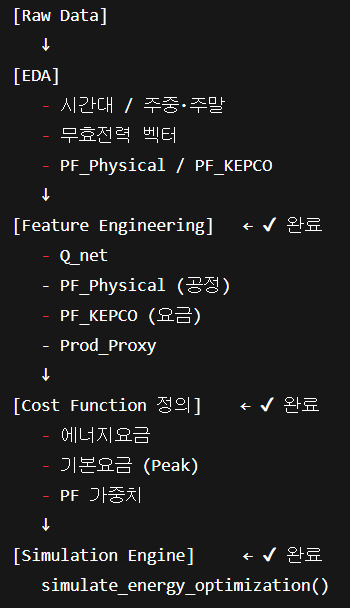

### <b> 

# <b> -- < tCO₂ 계산 로직 (Baseline) > -- 
* 아래 parameter들은 예시 값임 _ API 활용하여 함수 재정의 필요

In [37]:
import pandas as pd
import numpy as np

# --- [설정값 정의] ---
EMISSION_FACTOR = {2018: 0.000466, 2020: 0.000445, 2022: 0.000430, 2024: 0.000415, 2026: 0.000390}
CARBON_PRICE = {2018: 25000, 2020: 30000, 2022: 35000, 2024: 45000, 2026: 60000}

# --- [비용 계산 함수 정의] ---

def calculate_all_costs(df):
    # 1. 단가 매핑 및 전력량 요금 (Energy_Cost)
    # 이미 get_unit_price 함수가 정의되어 있다고 가정합니다.
    df['unit_price'] = df.apply(get_unit_price, axis=1)
    df['Energy_Cost_KRW'] = df['Usage_kWh'] * df['unit_price']

    # 2. 역률 페널티 (PF_Penalty)
    # 15분 데이터이므로 기본요금을 해당 시간만큼 쪼개서 적용 (비정상 수치 방지)
    def get_fixed_penalty(row):
        pf = row['Power_Factor']
        # 월 기본요금(6160원)을 15분 단위 개수(약 2976개)로 나눔
        basic_rate_per_15min = 6160.0 / (31 * 24 * 4) 
        basic_cost = (row['Usage_kWh'] * 4) * basic_rate_per_15min
        
        diff = pf - 90
        if diff >= 0:
            adj_rate = -min(diff, 25) * 0.002  # 할인
        else:
            adj_rate = min(abs(diff), 100) * 0.002 # 할증
        return basic_cost * adj_rate

    df['PF_Penalty_KRW'] = df.apply(get_fixed_penalty, axis=1)

    # 3. 탄소 비용 (Carbon_Cost)
    df['Emission_Factor'] = df['Year'].map(lambda y: EMISSION_FACTOR.get(y, 0.000390))
    df['Carbon_Price'] = df['Year'].map(lambda y: CARBON_PRICE.get(y, 60000))
    
    df['tCO2'] = df['Usage_kWh'] * df['Emission_Factor']
    df['Carbon_Cost_KRW'] = df['tCO2'] * df['Carbon_Price']

    # 4. 최종 통합 비용
    df['Total_Cost_With_Carbon'] = (
        df['Energy_Cost_KRW'] + 
        df['PF_Penalty_KRW'] + 
        df['Carbon_Cost_KRW']
    )
    
    return df

# 실행
CO2_df = calculate_all_costs(df)
print(CO2_df[['Energy_Cost_KRW', 'PF_Penalty_KRW', 'Carbon_Cost_KRW', 'Total_Cost_With_Carbon']].head())

   Energy_Cost_KRW  PF_Penalty_KRW  Carbon_Cost_KRW  Total_Cost_With_Carbon
0          200.027        4.685895          36.9305              241.643395
1          252.400        5.917066          46.6000              304.917066
2          204.444        4.790941          37.7460              246.980941
3          208.861        4.895646          38.5615              252.318146
4          241.042        5.652096          44.5030              291.197096


In [36]:
import pandas as pd
import requests

# 1. API로부터 데이터를 가져오는 가상의 함수
def get_carbon_data_from_api():
    """
    실제 API 엔드포인트에서 탄소 계수와 가격 정보를 가져옵니다.
    """
    try:
        # 예시 API 주소 (실제 운영되는 API URL로 변경 필요)
        # response = requests.get("https://api.carbon-data.com/v1/factors")
        # data = response.json()
        
        # API 응답 결과가 아래와 같다고 가정합니다.
        api_data = {
            'factors': {2018: 0.000466, 2020: 0.000445, 2022: 0.000430, 2024: 0.000415, 2026: 0.000390},
            'prices': {2018: 25000, 2020: 30000, 2022: 35000, 2024: 45000, 2026: 60000}
        }
        return api_data['factors'], api_data['prices']
    
    except Exception as e:
        print(f"API 호출 오류: {e}")
        # 오류 발생 시 사용할 기본값(Backup) 설정
        return {2026: 0.000390}, {2026: 60000}

# 2. 통합 비용 계산 함수 (API 적용 버전)
def calculate_costs_with_api(df):
    # API 호출 (함수 내부나 외부에서 한 번만 실행)
    api_factors, api_prices = get_carbon_data_from_api()
    
    # [전력 및 페널티 계산 로직은 기존과 동일]
    df['unit_price'] = df.apply(get_unit_price, axis=1)
    df['Energy_Cost_KRW'] = df['Usage_kWh'] * df['unit_price']
    
    # 3. 탄소 데이터 매핑 (API에서 받아온 값 사용)
    # map() 함수를 사용하여 연도별로 API 값을 매칭합니다.
    df['Emission_Factor'] = df['Year'].map(lambda y: api_factors.get(y, 0.000390))
    df['Carbon_Price'] = df['Year'].map(lambda y: api_prices.get(y, 60000))
    
    # 4. 탄소 비용 및 합계 계산
    df['tCO2'] = df['Usage_kWh'] * df['Emission_Factor']
    df['Carbon_Cost_KRW'] = df['tCO2'] * df['Carbon_Price']
    
    df['Total_Cost_With_Carbon'] = (
        df['Energy_Cost_KRW'] + 
        df['PF_Penalty_KRW'] + 
        df['Carbon_Cost_KRW']
    )
    
    return df

# 실행
CO2_df = calculate_costs_with_api(df)
print(CO2_df[['Energy_Cost_KRW', 'PF_Penalty_KRW', 'Carbon_Cost_KRW', 'Total_Cost_With_Carbon']].head())

   Energy_Cost_KRW  PF_Penalty_KRW  Carbon_Cost_KRW  Total_Cost_With_Carbon
0          200.027        4.685895          36.9305              241.643395
1          252.400        5.917066          46.6000              304.917066
2          204.444        4.790941          37.7460              246.980941
3          208.861        4.895646          38.5615              252.318146
4          241.042        5.652096          44.5030              291.197096


In [18]:
df.columns

Index(['date', 'Usage_kWh', 'Lagging_Current_Reactive_Power_kVarh',
       'Leading_Current_Reactive_Power_kVarh', 'CO2_ppm',
       'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM',
       'WeekStatus', 'Day_of_week', 'Load_Type', 'Hour', 'DayOfWeek', 'Month',
       'Year', 'Is_Weekend', 'Season', 'Is_Peak_Cost_Hour',
       'Total_Reactive_Power', 'Reactive_Usage_Ratio', 'Apparent_Power',
       'Power_Factor', 'Usage_Moving_Avg_1h', 'Production_Capacity_Pct',
       'Q_net', 'PF_Physical', 'PF_Lagging', 'PF_Leading', 'Q_total_abs',
       'Motor_Ratio', 'Capacitor_Ratio', 'Over_Correction_Flag', 'PF_KEPCO',
       'Cost_with_PF', 'Effective_Power', 'Prod_Proxy', 'PF_Penalty_KRW',
       'unit_price', 'Energy_Cost_KRW'],
      dtype='object')

In [19]:
import pandas as pd

# 1. 연도별 설정값 정의
EMISSION_FACTOR_BY_YEAR = {2018: 0.000466, 2020: 0.000445, 2022: 0.000430, 2024: 0.000415, 2026: 0.000390}
CARBON_PRICE_BY_YEAR = {2018: 25000, 2020: 30000, 2022: 35000, 2024: 45000, 2026: 60000}

# 2. 전력 요금 및 역률 페널티 계산 (시뮬레이션 코드 로직 기반)
df['Energy_Cost_KRW'] = df['Usage_kWh'] * df['unit_price'] # unit_price가 있다면 사용
df['PF_Penalty_KRW'] = df.apply(calculate_pf_penalty, axis=1)

# 3. 매핑 (Mapping) - lambda보다 훨씬 빠릅니다.
df['Emission_Factor'] = df['Year'].map(lambda y: EMISSION_FACTOR_BY_YEAR.get(y, 0.000390))
df['Carbon_Price'] = df['Year'].map(lambda y: CARBON_PRICE_BY_YEAR.get(y, 60000))

# 4. 탄소 배출량 및 탄소 비용 계산
# tCO2 = 사용량(kWh) * 배출계수(tCO2/kWh)
df['tCO2'] = df['Usage_kWh'] * df['Emission_Factor']

# Carbon_Cost_KRW = 탄소배출량(tCO2) * 탄소가격(원/tCO2)
df['Carbon_Cost_KRW'] = df['tCO2'] * df['Carbon_Price']


# 5. 최종 통합 비용 계산 (전기요금 + 탄소비용)
# 주의: 기존 피처명(Energy_Cost_KRW, PF_Penalty_KRW)이 데이터프레임에 존재해야 합니다.
df['Total_Cost_With_Carbon'] = (
                                    df['Energy_Cost_KRW'] + 
                                    df['PF_Penalty_KRW'] + 
                                    df['Carbon_Cost_KRW']
                                )

print(df[['Usage_kWh', 'tCO2', 'Carbon_Cost_KRW', 'Total_Cost_With_Carbon']].head())

   Usage_kWh      tCO2  Carbon_Cost_KRW  Total_Cost_With_Carbon
0       3.17  0.001477          36.9305            14182.181993
1       4.00  0.001864          46.6000            17908.188391
2       3.24  0.001510          37.7460            14500.031025
3       3.31  0.001542          38.5615            14816.864315
4       3.82  0.001780          44.5030            17106.182064


### <b> (1) 연도별 전력 탄소 계수 설계
> 국가 전력 믹스 개선을 반영하여,
kWh당 탄소 배출 계수는 연도에 따라 점진적으로 감소하는 것으로 가정한다.


> 탄소 가격 (KAU) <br>
> 한국 배출권거래제(K-ETS)의 배출권 가격은 한국거래소(KRX)에서 연도별·시기별로 공시

In [20]:
# 연도별 전력 탄소 배출 계수 (tCO2 / kWh)
EMISSION_FACTOR_BY_YEAR = {
                                2018: 0.000466,
                                2020: 0.000450,
                                2022: 0.000430,
                                2024: 0.000410,
                                2026: 0.000390
                            }

def get_emission_factor(year):
    return EMISSION_FACTOR_BY_YEAR.get(year, 0.000390)

### <b> (2) tCO₂ 계산

In [21]:
df['Emission_Factor'] = df['Year'].apply(get_emission_factor)
df['tCO2'] = df['Usage_kWh'] * df['Emission_Factor']

### <b> (3) 탄소 비용 함수 (정책 반영 핵심)
> 연도별 탄소 가격 시나리오 <br>
> 탄소 비용은 배출권 거래제의 가격 변동성을 고려 <br>
> -> 연도별 시나리오 파라미터로 정의

In [22]:
CARBON_PRICE_BY_YEAR = {
                            2018: 25000,
                            2020: 30000,
                            2022: 35000,
                            2024: 45000,
                            2026: 60000
                        }

def get_carbon_price(year):
    return CARBON_PRICE_BY_YEAR.get(year, 60000)

#### <b> (3-1) 연도별 탄소 배출 계수

In [23]:
def grid_emission_factor(year: int) -> float:
    """
    연도별 전력 탄소 배출 계수 (tCO2 per kWh)
    정책 변화 및 전력 믹스 개선을 반영한 추정 값.
    """
    factor_table = {
        2018: 0.000466,
        2020: 0.000445,
        2022: 0.000430,
        2024: 0.000415,
        2026: 0.000390
    }
    return factor_table.get(year, 0.000390)  # default: 최신 추정치

#### <b> (3-2) 연도별 탄소 가격 함수

In [24]:
def carbon_price_krw(year: int) -> float:
    """
    연도별 탄소 배출권 가격(KRW / tCO2)
    KAU(KR ETS) 시장 가격 및 정책 예상치를 기반으로 설계.
    """

    price_table = {
        2018: 25000,
        2020: 30000,
        2022: 35000,
        2024: 45000,
        2026: 55000
    }
    return price_table.get(year, 55000)  # default: 정책 강도 높은 시나리오

#### <b> (3-3) 탄소 비용 계산 함수

In [25]:
def calculate_carbon_cost(df):
    """
    df must include:
        - 'Usage_kWh'
        - 'date' (datetime)
    This function returns:
        - df with 'tCO2', 'Carbon_Cost'
    """

    # 탄소 배출량
    df['tCO2'] = df.apply(
        lambda row: row['Usage_kWh'] * grid_emission_factor(row['Year']),
        axis=1
    )

    # 탄소 비용
    df['Carbon_Cost'] = df.apply(
        lambda row: row['tCO2'] * carbon_price_krw(row['Year']),
        axis=1
    )

    return df

#### <b> (3-4) 최종 비용 함수에 통합

In [27]:
df.columns

Index(['date', 'Usage_kWh', 'Lagging_Current_Reactive_Power_kVarh',
       'Leading_Current_Reactive_Power_kVarh', 'CO2_ppm',
       'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM',
       'WeekStatus', 'Day_of_week', 'Load_Type', 'Hour', 'DayOfWeek', 'Month',
       'Year', 'Is_Weekend', 'Season', 'Is_Peak_Cost_Hour',
       'Total_Reactive_Power', 'Reactive_Usage_Ratio', 'Apparent_Power',
       'Power_Factor', 'Usage_Moving_Avg_1h', 'Production_Capacity_Pct',
       'Q_net', 'PF_Physical', 'PF_Lagging', 'PF_Leading', 'Q_total_abs',
       'Motor_Ratio', 'Capacitor_Ratio', 'Over_Correction_Flag', 'PF_KEPCO',
       'Cost_with_PF', 'Effective_Power', 'Prod_Proxy', 'PF_Penalty_KRW',
       'unit_price', 'Energy_Cost_KRW', 'Emission_Factor', 'Carbon_Price',
       'tCO2', 'Carbon_Cost_KRW', 'Total_Cost_With_Carbon', 'Carbon_Cost'],
      dtype='object')

In [28]:
# 예시: 기존 비용이 df['Total_Cost']로 존재한다면
df = calculate_carbon_cost(df)
df['Total_Cost'] = df['Energy_Cost_KRW'] + df['PF_Penalty_KRW']

# 최종 비용 계산
df['Total_Cost_With_Carbon'] = ( df['Total_Cost'] + df['Carbon_Cost'] )

### <b> (4) 탄소 비용 계산

In [29]:
df['Carbon_Price'] = df['Year'].apply(get_carbon_price)
df['Carbon_Cost_KRW'] = df['tCO2'] * df['Carbon_Price']

### <b> （5） 총 비용 구조 (보고서에서 제일 중요한 그림)
> 초기 분석에서는 탄소 비용이 전체 비용에서 차지하는 비중이 작아 보일 수 있다. <br>
그러나 동일한 공정 패턴을 2026년 정책 환경에 투영할 경우,<br>
탄소 비용은 PF 페널티와 유사한 수준의 비용 요인으로 성장한다.

In [30]:
df['Total_Cost_With_Carbon'] = (
                                    df['Energy_Cost_KRW'] +
                                    df['PF_Penalty_KRW'] +
                                    df['Carbon_Cost_KRW']
                                )

In [31]:
print(df[['Energy_Cost_KRW', 'PF_Penalty_KRW', 'Carbon_Cost_KRW', 'Total_Cost_With_Carbon']].head())

   Energy_Cost_KRW  PF_Penalty_KRW  Carbon_Cost_KRW  Total_Cost_With_Carbon
0          200.027    13945.224493          36.9305            14182.181993
1          252.400    17609.188391          46.6000            17908.188391
2          204.444    14257.841025          37.7460            14500.031025
3          208.861    14569.441815          38.5615            14816.864315
4          241.042    16820.637064          44.5030            17106.182064


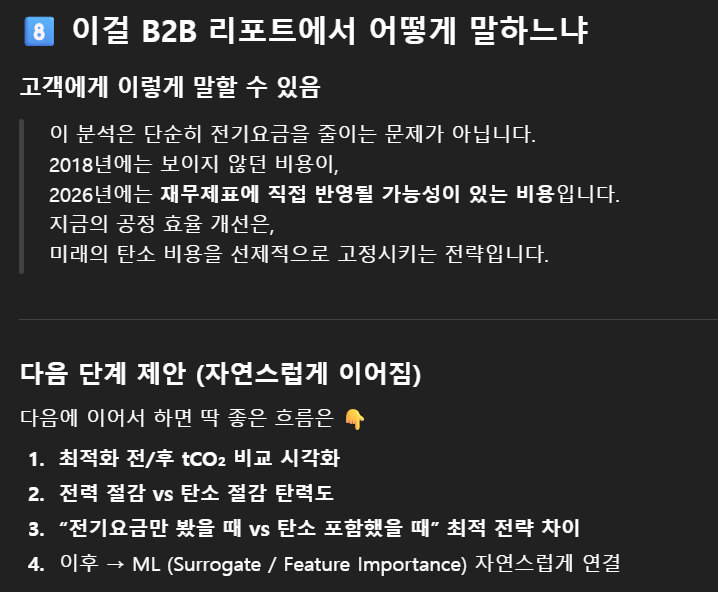

### <b> 